In [28]:
print("Hola Luristán")

Hola Luristán


In [2]:
### IMPORTS ###
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import optuna
from optuna.pruners import MedianPruner
import xgboost as xgb
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, matthews_corrcoef
)
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import missingno as msno
import seaborn as sns
from sklearn.impute import SimpleImputer, MissingIndicator

warnings.filterwarnings('ignore')

# ── GPU DETECTION ─────────────────────────────────────────────────────────────
# We use torch only for detection — it's the most reliable way to check CUDA
# availability without depending on XGBoost internals.
# If torch is not installed, we fall back to CPU silently.
try:
    import torch
    print(torch.__version__)
    print(torch.cuda.is_available())
    print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")
    USE_GPU = torch.cuda.is_available()
except ImportError:
    USE_GPU = False

if USE_GPU:
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU detected: {gpu_name} — XGBoost will use CUDA.")
else:
    print("No GPU detected — running on CPU. All models work normally.")

# Trials per model: increase if you have GPU to take advantage of faster XGBoost tuning.
# Anyone running on CPU can lower this (e.g. 10–15) to reduce waiting time.
N_TRIALS_PER_MODEL = 50 if USE_GPU else 20

# ─────────────────────────────────────────────────────────────────────────────

No GPU detected — running on CPU. All models work normally.


DATA PROCESSING

In [3]:
### DATASET LOADING ###

#Lo antiguo de Jon
#gauth = GoogleAuth()
#gauth.LocalWebserverAuth()
#drive = GoogleDrive(gauth)

# Google Drive ID for public sharing of the dataset
#file_id = "1aGGJNl1VtET_6HqQh81ouSKqe6-lN-OG"
#file = drive.CreateFile({"id": file_id})
#file.GetContentFile("ai_tools.csv")

# Reading the csv and loading it into a pandas dataframe.
#df = pd.read_csv("ai_tools.csv")
#df.head()

url = "https://raw.githubusercontent.com/GafillaAbrahamer/ClassificationProject/refs/heads/main/AI_Landscape_19k_Tools_2026.csv"
df = pd.read_csv(url)
df.head()

# The target is already a categorical multiclass column — no transformation needed.
# Classes: "Free", "Freemium", "Subscription", "Pay-as-you-go", "Open Source", "Usage-Based"

# We remove the target from the features to avoid data leakage.
X = df.drop(["Primary_Domain", "Intelligence_Type"], axis=1) #intelligence type is also removed to avoid data leakage, as it is highly correlated with the primary domain and could give away the label. (correlation matrix abajo pero efectivamente es la más correlada con el primary domain)

# We only keep the label.
y = df["Intelligence_Type"]

print(X)
print(y)

               AI_Name     Developer  Release_Year  \
0             Scrip Ai       Scripai          2024   
1             Quickads      Quickads          2025   
2           Wonderchat    Wonderchat          2024   
3         Creatosaurus  Creatosaurus          2023   
4                Blobr         Blobr          2025   
...                ...           ...           ...   
19324         Emozi Ai         Emozi          2025   
19325        Myresumai     Myresumai          2022   
19326  Code Screenshot            Cs          2024   
19327      Ho Ho Hello     Hohohello          2022   
19328             Puti          Puti          2024   

                                       Key_Functionality  Pricing_Model  \
0      Free AI writer for creating viral short video ...  Pay-as-you-go   
1      AI ad generator for creating image and video a...  Pay-as-you-go   
2      AI Chatbot builder to create custom ChatGPT ch...       Freemium   
3      All-in-one creative and marketing platform f

In [4]:
### MISSING DATA ANALYSIS ###

# Total missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Percentage of missing values per column
print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Quick summary: any missing at all?
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
AI_Name                 0
Developer               0
Release_Year            0
Intelligence_Type       0
Primary_Domain          0
Key_Functionality       0
Pricing_Model           0
API_Availability        0
Context_Window       3877
Accessibility           0
Website_URL             0
Popularity_Votes        0
dtype: int64

Missing values (%):
AI_Name               0.00
Developer             0.00
Release_Year          0.00
Intelligence_Type     0.00
Primary_Domain        0.00
Key_Functionality     0.00
Pricing_Model         0.00
API_Availability      0.00
Context_Window       20.06
Accessibility         0.00
Website_URL           0.00
Popularity_Votes      0.00
dtype: float64

Total missing values in dataset: 3877


In [5]:
### TRANSFORMATION PIPELINE ###
# We drop non-informative columns
cols_to_drop = ['AI_Name', 'Developer', 'Website_URL', 'Key_Functionality'] #se quita el primary domain y el tipo de inteligencia para evitar data leakage
X = df.drop(columns=cols_to_drop)

# Train / Validation / Test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
X_train['Context_Window'] = X_train['Context_Window'].fillna('N/A')
X_val['Context_Window']   = X_val['Context_Window'].fillna('N/A')
X_test['Context_Window']  = X_test['Context_Window'].fillna('N/A')

print(f"Train size:      {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size:       {X_test.shape[0]}")

# We define column groups for encoding
ordinal_cols = ['Context_Window']
ordinal_categories = [['N/A', '8k', '32k', '128k', '1M']]  # explicit order

onehot_cols = ['API_Availability', 'Accessibility']

numerical_cols = ['Release_Year', 'Popularity_Votes']

# we build the ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    ('scaler', StandardScaler(), numerical_cols),
])

# we fit ONLY on train, then transform each split
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

# Optional: recover a readable DataFrame
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
feature_names = ordinal_cols + list(onehot_feature_names) + numerical_cols

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_processed   = pd.DataFrame(X_val_processed,   columns=feature_names)
X_test_processed  = pd.DataFrame(X_test_processed,  columns=feature_names)

print(X_train_processed.head())
print(f"\nFinal shape — Train: {X_train_processed.shape}, Val: {X_val_processed.shape}, Test: {X_test_processed.shape}")

Train size:      15463
Validation size: 1933
Test size:       1933
   Context_Window  API_Availability_No  API_Availability_Waitlist  \
0             4.0                  0.0                        0.0   
1             4.0                  0.0                        1.0   
2             1.0                  0.0                        0.0   
3             0.0                  0.0                        1.0   
4             1.0                  0.0                        0.0   

   API_Availability_Yes  Accessibility_API  Accessibility_Browser Extension  \
0                   1.0                1.0                              0.0   
1                   0.0                0.0                              0.0   
2                   1.0                0.0                              0.0   
3                   0.0                1.0                              0.0   
4                   1.0                0.0                              0.0   

   Accessibility_Desktop  Accessibility_Mob

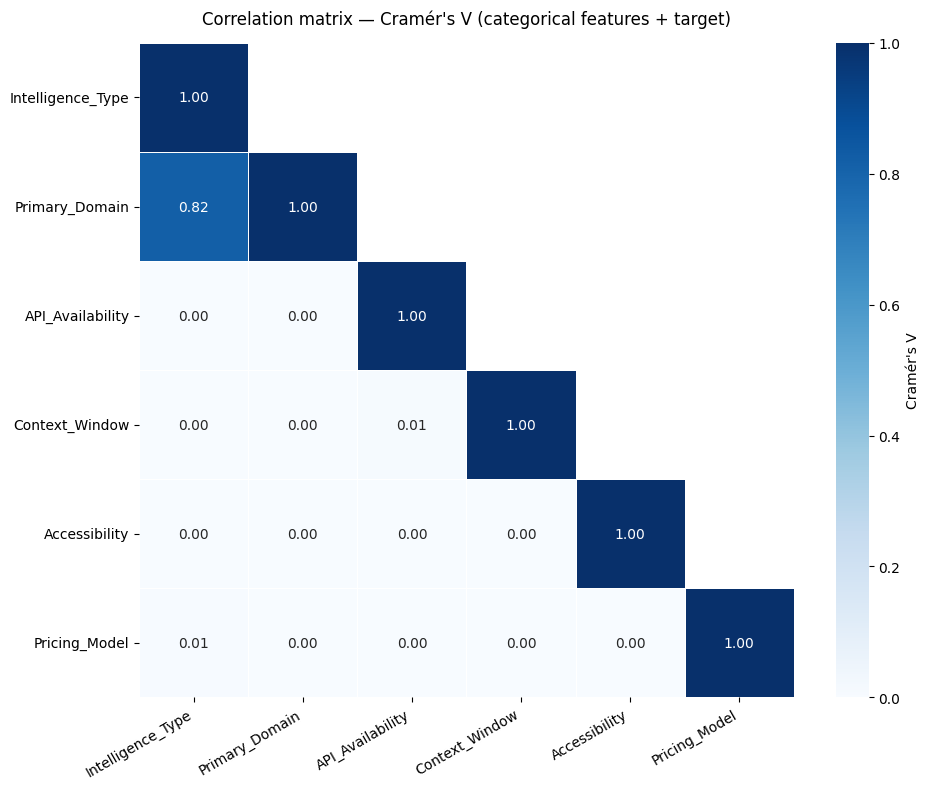


Cramér's V con Pricing_Model (target):
Intelligence_Type    0.007
Accessibility        0.002
Primary_Domain       0.000
API_Availability     0.000
Context_Window       0.000


In [6]:
### CORRELATION MATRIX ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ── Cramér's V (para variables categóricas) ────────────────────────────────
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# ── Columnas originales (sin encodear) ────────────────────────────────────
cat_cols = [
    'Intelligence_Type',
    'Primary_Domain',
    'API_Availability',
    'Context_Window',
    'Accessibility',
    'Pricing_Model',   # target incluido para ver correlación con features
]

df_corr = df[cat_cols].fillna('N/A')

# ── Calcular matriz ────────────────────────────────────────────────────────
n = len(cat_cols)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

for i in cat_cols:
    for j in cat_cols:
        corr_matrix.loc[i, j] = cramers_v(df_corr[i], df_corr[j])

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # triángulo superior

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1,
    mask=mask,           # quitar si quieres la matriz completa
    square=True,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V"},
)

plt.title("Correlation matrix — Cramér's V (categorical features + target)", pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ── Correlaciones con el target ordenadas ─────────────────────────────────
print("\nCramér's V con Pricing_Model (target):")
target_corr = corr_matrix['Pricing_Model'].drop('Pricing_Model').sort_values(ascending=False)
print(target_corr.round(3).to_string())

IMBALANCE ANALYSIS AND MITIGATION

Class distribution analysis

In [7]:
# --- Class distribution analysis ---
# From 3.1: same pattern as df['annotation'].value_counts()

class_counts = y.value_counts()
print(f"The class distribution is:\n{class_counts}")

class_percentages = (class_counts / class_counts.sum()) * 100
print(f"\nThe class percentage distribution is:\n{class_percentages.round(2)}")

The class distribution is:
Intelligence_Type
Multimodal Generative AI       13722
Computer Vision / Diffusion     2108
Large Language Model (LLM)      1429
Autonomous Agent                 672
Code Intelligence                541
Speech-to-Text / TTS             500
Generative Video                 357
Name: count, dtype: int64

The class percentage distribution is:
Intelligence_Type
Multimodal Generative AI       70.99
Computer Vision / Diffusion    10.91
Large Language Model (LLM)      7.39
Autonomous Agent                3.48
Code Intelligence               2.80
Speech-to-Text / TTS            2.59
Generative Video                1.85
Name: count, dtype: float64


Bar chart

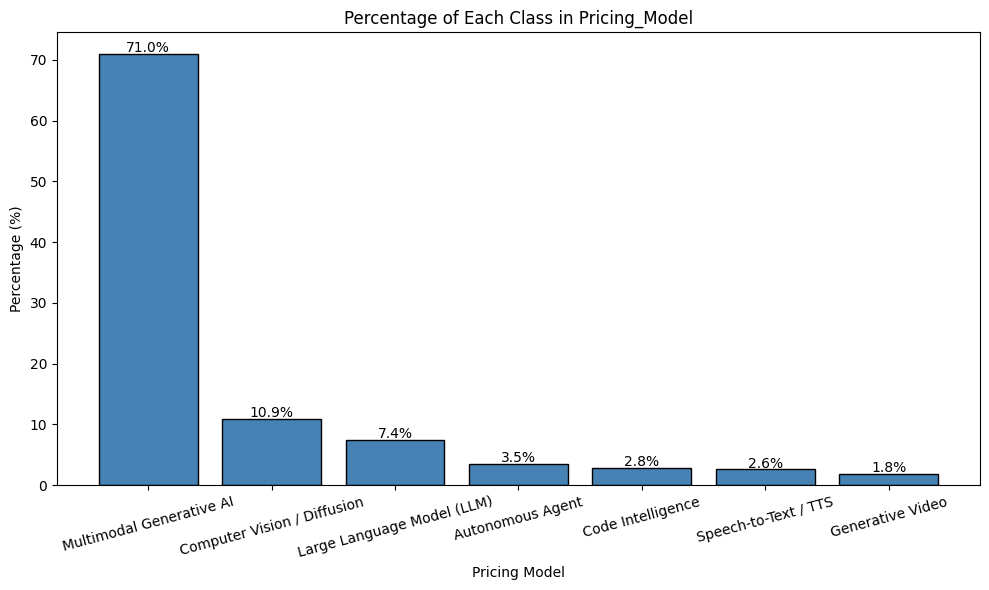

In [8]:
# --- Bar chart of class distribution ---
# From 3.1: adapted from the pie chart cell

plt.figure(figsize=(10, 6))
plt.bar(class_percentages.index, class_percentages.values, color='steelblue', edgecolor='black')
plt.title('Percentage of Each Class in Pricing_Model')
plt.xlabel('Pricing Model')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
for i, v in enumerate(class_percentages.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

class_distribution helper function

In [9]:
# --- Helper function to print class distribution ---
# From 3.1: class_distribution() function, copied exactly

def class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    total_samples = len(y)
    percentages = (counts / total_samples) * 100
    distribution = dict(zip(unique, zip(counts, percentages)))

    for class_label, (count, percentage) in distribution.items():
        print(f'Class {class_label}: {count} samples, {percentage:.2f}% of the dataset')

run_pipeline helper function

In [10]:
# --- Helper function to run and evaluate a pipeline ---
# From 3.2: run_pipeline() function, copied exactly, 
# adapted to use macro averaging since this is multiclass

def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("Experiment name: " + exp_name)
    print("Accuracy:  ", round(accuracy_score(y_test, y_pred), 4))
    print("Precision: ", round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("Recall:    ", round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("F1:        ", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print(f"Predicted class distribution:\n{pd.Series(y_pred).value_counts()}")
    print()

Baseline: no mitigation

In [11]:
# --- Baseline: no imbalance mitigation ---
# From 3.2: same structure as run_pipeline experiments

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("=" * 50)
print("BASELINE — No mitigation")
print("=" * 50)
class_distribution(y_train_encoded)   # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

pipe_baseline = LogisticRegression(max_iter=1000, random_state=42)
run_pipeline(pipe_baseline, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "Baseline (no mitigation)")       # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

BASELINE — No mitigation
Class 0: 538 samples, 3.48% of the dataset
Class 1: 433 samples, 2.80% of the dataset
Class 2: 1686 samples, 10.90% of the dataset
Class 3: 286 samples, 1.85% of the dataset
Class 4: 1143 samples, 7.39% of the dataset
Class 5: 10977 samples, 70.99% of the dataset
Class 6: 400 samples, 2.59% of the dataset
Experiment name: Baseline (no mitigation)
Accuracy:   0.7098
Precision:  0.1014 (macro)
Recall:     0.1429 (macro)
F1:         0.1186 (macro)
Predicted class distribution:
5    1933
Name: count, dtype: int64



class_weight='balanced'

In [12]:
# --- class_weight='balanced' ---
# From 3.1: LogisticRegression(class_weight='balanced') pattern

print("=" * 50)
print("CLASS WEIGHT — balanced")
print("=" * 50)

pipe_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
run_pipeline(pipe_balanced, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "class_weight='balanced'")       # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

CLASS WEIGHT — balanced
Experiment name: class_weight='balanced'
Accuracy:   0.0745
Precision:  0.1505 (macro)
Recall:     0.1472 (macro)
F1:         0.0688 (macro)
Predicted class distribution:
3    518
0    385
1    289
4    271
6    233
2    148
5     89
Name: count, dtype: int64



 Oversampling techniques compared

In [13]:
# --- Oversampling and combined techniques compared ---
# From 3.2: Exercise 1 run_pipeline loop pattern, using ImbPipeline

print("=" * 50)
print("RESAMPLING TECHNIQUES COMPARISON")
print("=" * 50)

samplers = [
    (RandomOverSampler(random_state=42),  "RandomOverSampler"),
    (SMOTE(random_state=42),              "SMOTE"),
    (ADASYN(random_state=42),             "ADASYN"),
    (RandomUnderSampler(random_state=42), "RandomUnderSampler"),
    (SMOTEENN(random_state=42),           "SMOTEENN"),
    (SMOTETomek(random_state=42),         "SMOTETomek"),
]

for sampler, name in samplers:
    pipe = ImbPipeline([
        ('resample',    sampler),
        ('classifier',  LogisticRegression(max_iter=1000, random_state=42)),
    ])
    run_pipeline(pipe, X_train_processed, X_test_processed,
                 y_train_encoded, y_test_encoded, name)      # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

RESAMPLING TECHNIQUES COMPARISON
Experiment name: RandomOverSampler
Accuracy:   0.0745
Precision:  0.1462 (macro)
Recall:     0.1517 (macro)
F1:         0.0703 (macro)
Predicted class distribution:
3    528
0    362
1    301
6    243
2    213
4    194
5     92
Name: count, dtype: int64

Experiment name: SMOTE
Accuracy:   0.0817
Precision:  0.1494 (macro)
Recall:     0.1611 (macro)
F1:         0.0754 (macro)
Predicted class distribution:
3    534
0    326
1    323
4    265
6    198
2    188
5     99
Name: count, dtype: int64

Experiment name: ADASYN
Accuracy:   0.0931
Precision:  0.1615 (macro)
Recall:     0.1616 (macro)
F1:         0.0829 (macro)
Predicted class distribution:
3    553
0    333
1    278
6    275
2    200
4    171
5    123
Name: count, dtype: int64

Experiment name: RandomUnderSampler
Accuracy:   0.0864
Precision:  0.1501 (macro)
Recall:     0.1366 (macro)
F1:         0.0709 (macro)
Predicted class distribution:
0    427
3    417
1    319
4    303
6    214
2    130
5    

Class distribution after best resampler

In [14]:
# --- Inspect class distribution after resampling ---
# From 3.1: class_distribution() usage after fit_resample

print("Class distribution BEFORE resampling:")
class_distribution(y_train_encoded)      

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train_encoded)     
print("\nClass distribution AFTER SMOTE resampling:")
class_distribution(y_resampled)

Class distribution BEFORE resampling:
Class 0: 538 samples, 3.48% of the dataset
Class 1: 433 samples, 2.80% of the dataset
Class 2: 1686 samples, 10.90% of the dataset
Class 3: 286 samples, 1.85% of the dataset
Class 4: 1143 samples, 7.39% of the dataset
Class 5: 10977 samples, 70.99% of the dataset
Class 6: 400 samples, 2.59% of the dataset

Class distribution AFTER SMOTE resampling:
Class 0: 10977 samples, 14.29% of the dataset
Class 1: 10977 samples, 14.29% of the dataset
Class 2: 10977 samples, 14.29% of the dataset
Class 3: 10977 samples, 14.29% of the dataset
Class 4: 10977 samples, 14.29% of the dataset
Class 5: 10977 samples, 14.29% of the dataset
Class 6: 10977 samples, 14.29% of the dataset


PARTE DE 3.3 (3.4 NO NOS SIRVE)

Missingness analysis

In [15]:
# From 3.3: same pattern as df.isnull().sum() block
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2)[df.isnull().sum() > 0])

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
Context_Window    3877
dtype: int64

Missing values (%):
Context_Window    20.06
dtype: float64

Total missing values in dataset: 3877


Missingno matrix and heatmap

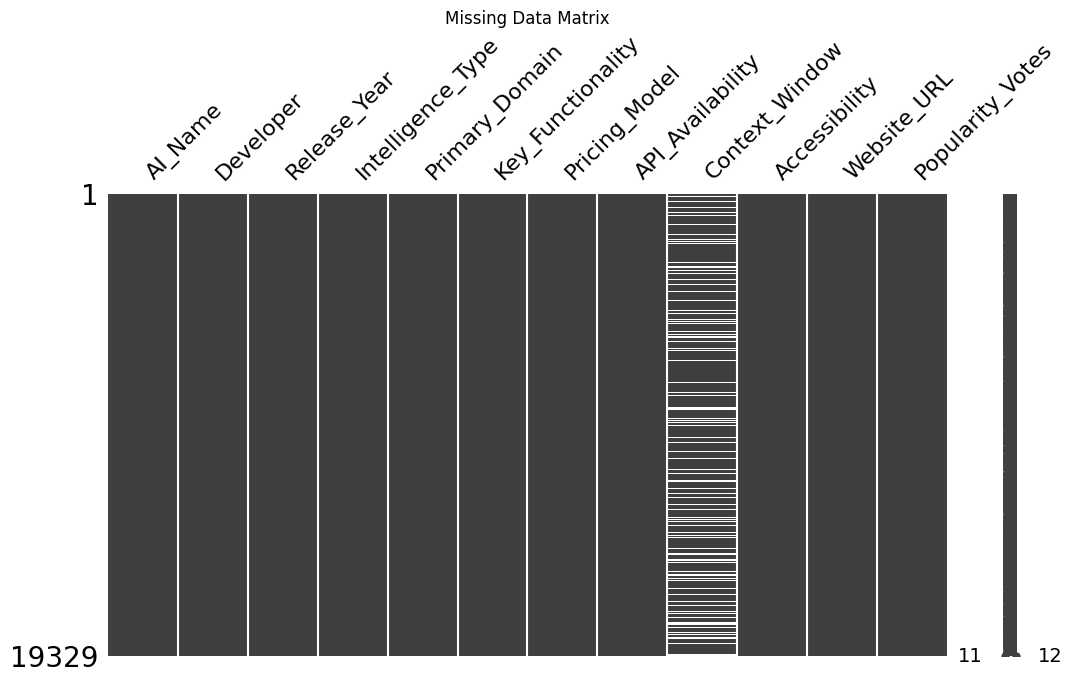

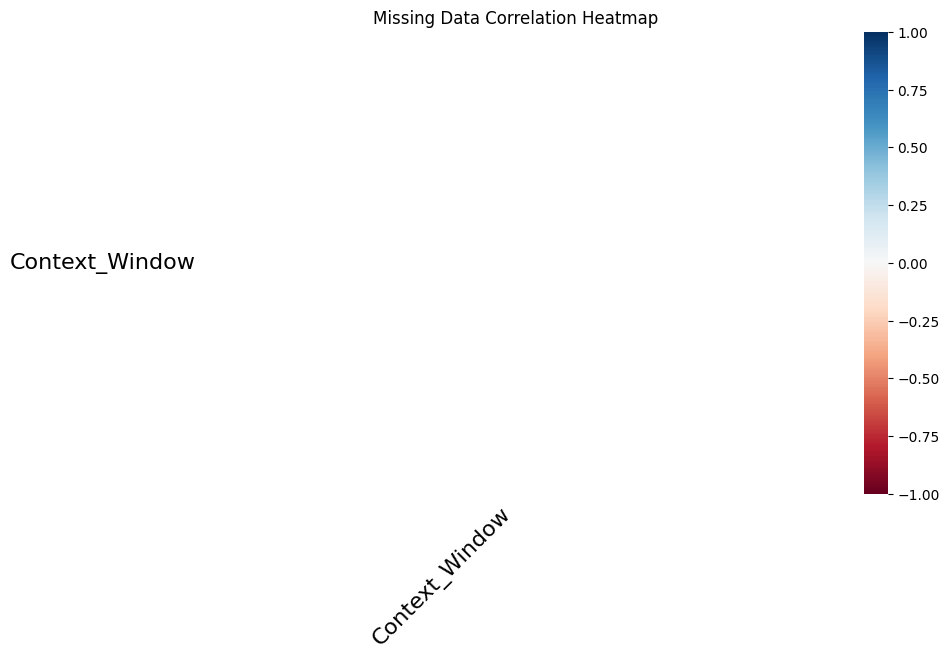

In [16]:
# From 3.3 Exercise 1: missingno matrix and heatmap, copied exactly

msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix')
plt.show()

msno.heatmap(df, figsize=(10, 6))
plt.title('Missing Data Correlation Heatmap')
plt.show()

Distribution of Context_Window before imputation

In [17]:
# From 3.3: compare_distributions helper, copied exactly

def compare_distributions(original, imputed, imputing_technique, feature):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(original[feature].dropna(), kde=False, color="blue", label="Original")
    plt.title('Original {} Distribution'.format(feature))
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(imputed[feature].dropna(), kde=False, color="green",
                 label="{} Imputed".format(imputing_technique))
    plt.title('{} Imputed {} Distribution'.format(imputing_technique, feature))
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Crear la variable indicadora
df['Has_Context_Window'] = df['Context_Window'].notna().astype(int)

Missingness indicator

In [19]:
# From 3.3 Exercise 2b: add_indicator=True to track which rows were imputed
# Same pattern as the age_missing indicator in the Titanic example

imputer_with_indicator = SimpleImputer(strategy='most_frequent', add_indicator=True)
imputed_context = imputer_with_indicator.fit_transform(df[['Context_Window']])

df_copy['Context_Window'] = imputed_context[:, 0]
df_copy['Context_Window_missing'] = imputed_context[:, 1]

print("Missingness indicator added — first few rows:")
print(df_copy[['Context_Window', 'Context_Window_missing']].head(10))
print(f"\nRows that were imputed: {int(df_copy['Context_Window_missing'].sum())}")

Missingness indicator added — first few rows:
  Context_Window Context_Window_missing
0           128k                  False
1             8k                  False
2             8k                  False
3             8k                  False
4             8k                  False
5             1M                  False
6           128k                  False
7             1M                  False
8           128k                   True
9           128k                   True

Rows that were imputed: 3877


MODEL COMPARISON AND HYPERPARAMETER TUNING

In [20]:
# le, y_train_encoded, y_test_encoded, X_resampled, y_resampled
# are all defined in Point 2 — no need to redefine them here.

optuna.logging.set_verbosity(optuna.logging.WARNING)

# We store each study here so we can retrieve best params in the final cell
studies = {}

def build_model(name, params):
    """Reconstruct a model using the best params found by its Optuna study."""
    if name == "VotingSoft":
        return VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=params["rf_n_estimators"], random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            voting='soft'
        )
    elif name == "Bagging":
        return BaggingClassifier(
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            max_features=params["max_features"],
            random_state=42
        )
    elif name == "AdaBoost":
        return AdaBoostClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            random_state=42
        )
    elif name == "GradientBoosting":
        return GradientBoostingClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"],
            random_state=42
        )
    elif name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"],
            random_state=42,
            eval_metric='mlogloss',
            verbosity=0
        )
    elif name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            max_features=params["max_features"],
            min_samples_split=params["min_samples_split"],
            random_state=42
        )
    else:  # Stacking
        return StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            final_estimator=LogisticRegression(
                C=params["C"],
                max_iter=1000,
                random_state=42
            ),
            cv=3
        )

def make_progress_callback(model_name, n_trials):
    import time
    import threading

    start_time = time.time()
    lock = threading.Lock()
    printed = set()  # ← rastrea qué trials ya se imprimieron

    def callback(study, trial):
        with lock:
            completed = len([t for t in study.trials if t.state.name == "COMPLETE"])
            if completed in printed:  # ← si ya imprimimos este número, saltamos
                return
            printed.add(completed)

            elapsed   = time.time() - start_time
            avg       = elapsed / completed
            remaining = avg * (n_trials - completed)

            print(
                f"[{model_name}] "
                f"Trial {completed:>3}/{n_trials} | "
                f"Acc: {trial.value:.4f} | "
                f"Best: {study.best_value:.4f} | "
                f"~{remaining/60:.1f} min restantes"
            )

    return callback

In [ ]:
def objective_votingsoft(trial):
    clf = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
                random_state=42,
                n_jobs=-1
            )),
            # probability=True is required for soft voting — SVC does not
            # output probabilities by default, but soft voting needs them
            # to average class probabilities across estimators.
            ('svc', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=1).mean()

print("Optimizing VotingSoft...")
study_vs = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_vs.optimize(
    objective_votingsoft,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("VotingSoft", N_TRIALS_PER_MODEL)]
)
studies["VotingSoft"] = study_vs
print(f"  Best CV Accuracy: {study_vs.best_value:.4f}  |  Best params: {study_vs.best_params}")

Optimizing VotingSoft...


In [21]:
def objective_bagging(trial):
    clf = BaggingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 10, 200),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        max_features=trial.suggest_float("max_features", 0.5, 1.0),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=1).mean()

print("Optimizing Bagging...")
study_bag = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_bag.optimize(
    objective_bagging,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("Bagging", N_TRIALS_PER_MODEL)]
)
studies["Bagging"] = study_bag
print(f"  Best CV Accuracy: {study_bag.best_value:.4f}  |  Best params: {study_bag.best_params}")

Optimizing Bagging...
[Bagging] Trial   1/50 | Acc: 0.7082 | Best: 0.7082 | ~47.0 min restantes
[Bagging] Trial   2/50 | Acc: 0.7027 | Best: 0.7082 | ~25.3 min restantes
[Bagging] Trial   3/50 | Acc: 0.4661 | Best: 0.7082 | ~17.8 min restantes
[Bagging] Trial   4/50 | Acc: 0.6086 | Best: 0.7082 | ~13.8 min restantes
[Bagging] Trial   5/50 | Acc: 0.6302 | Best: 0.7082 | ~10.8 min restantes
[Bagging] Trial   6/50 | Acc: 0.7095 | Best: 0.7095 | ~8.8 min restantes
[Bagging] Trial   7/50 | Acc: 0.6856 | Best: 0.7095 | ~7.4 min restantes
[Bagging] Trial   8/50 | Acc: 0.7051 | Best: 0.7095 | ~6.7 min restantes
[Bagging] Trial   9/50 | Acc: 0.6240 | Best: 0.7095 | ~5.9 min restantes
[Bagging] Trial  10/50 | Acc: 0.5587 | Best: 0.7095 | ~5.3 min restantes
[Bagging] Trial  11/50 | Acc: 0.7061 | Best: 0.7095 | ~4.8 min restantes
[Bagging] Trial  12/50 | Acc: 0.6849 | Best: 0.7095 | ~4.3 min restantes
[Bagging] Trial  13/50 | Acc: 0.5412 | Best: 0.7095 | ~4.0 min restantes
[Bagging] Trial  14/50 |

In [22]:
def objective_adaboost(trial):
    clf = AdaBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 2.0, log=True),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

print("Optimizing AdaBoost...")
study_ada = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_ada.optimize(
    objective_adaboost,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("AdaBoost", N_TRIALS_PER_MODEL)]
)
studies["AdaBoost"] = study_ada
print(f"  Best CV Accuracy: {study_ada.best_value:.4f}  |  Best params: {study_ada.best_params}")

Optimizing AdaBoost...
[AdaBoost] Trial   1/50 | Acc: 0.1640 | Best: 0.1640 | ~3.1 min restantes
[AdaBoost] Trial   2/50 | Acc: 0.1727 | Best: 0.1727 | ~2.2 min restantes
[AdaBoost] Trial   3/50 | Acc: 0.1841 | Best: 0.1841 | ~1.8 min restantes
[AdaBoost] Trial   4/50 | Acc: 0.1591 | Best: 0.1841 | ~1.7 min restantes
[AdaBoost] Trial   5/50 | Acc: 0.1434 | Best: 0.1841 | ~2.1 min restantes
[AdaBoost] Trial   6/50 | Acc: 0.1814 | Best: 0.1841 | ~1.9 min restantes
[AdaBoost] Trial   7/50 | Acc: 0.1479 | Best: 0.1841 | ~1.8 min restantes
[AdaBoost] Trial   8/50 | Acc: 0.1681 | Best: 0.1841 | ~1.8 min restantes
[AdaBoost] Trial   9/50 | Acc: 0.1941 | Best: 0.1941 | ~1.6 min restantes
[AdaBoost] Trial  10/50 | Acc: 0.1517 | Best: 0.1941 | ~1.4 min restantes
[AdaBoost] Trial  11/50 | Acc: 0.1825 | Best: 0.1941 | ~1.2 min restantes
[AdaBoost] Trial  12/50 | Acc: 0.1698 | Best: 0.1941 | ~1.2 min restantes
[AdaBoost] Trial  13/50 | Acc: 0.1952 | Best: 0.1952 | ~1.1 min restantes
[AdaBoost] Tria

In [24]:
def objective_gradientboosting(trial):
    clf = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

print("Optimizing GradientBoosting...")
study_gb = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_gb.optimize(
    objective_gradientboosting,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("GradientBoosting", N_TRIALS_PER_MODEL)]
)
studies["GradientBoosting"] = study_gb
print(f"  Best CV Accuracy: {study_gb.best_value:.4f}  |  Best params: {study_gb.best_params}")

Optimizing GradientBoosting...
[GradientBoosting] Trial   1/50 | Acc: 0.2151 | Best: 0.2151 | ~49.5 min restantes
[GradientBoosting] Trial   2/50 | Acc: 0.5261 | Best: 0.5261 | ~25.5 min restantes
[GradientBoosting] Trial   3/50 | Acc: 0.3412 | Best: 0.5261 | ~24.8 min restantes
[GradientBoosting] Trial   4/50 | Acc: 0.5329 | Best: 0.5329 | ~34.9 min restantes
[GradientBoosting] Trial   5/50 | Acc: 0.5383 | Best: 0.5383 | ~31.7 min restantes
[GradientBoosting] Trial   6/50 | Acc: 0.4386 | Best: 0.5383 | ~27.7 min restantes
[GradientBoosting] Trial   7/50 | Acc: 0.5746 | Best: 0.5746 | ~24.7 min restantes
[GradientBoosting] Trial   8/50 | Acc: 0.5162 | Best: 0.5746 | ~21.6 min restantes
[GradientBoosting] Trial   9/50 | Acc: 0.4178 | Best: 0.5746 | ~19.4 min restantes
[GradientBoosting] Trial  10/50 | Acc: 0.4243 | Best: 0.5746 | ~17.2 min restantes
[GradientBoosting] Trial  11/50 | Acc: 0.4673 | Best: 0.5746 | ~15.5 min restantes
[GradientBoosting] Trial  12/50 | Acc: 0.3424 | Best: 0.

In [25]:
def objective_xgboost(trial):
    clf = xgb.XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3,
                           scoring='accuracy', n_jobs=-1).mean()

print("Optimizing XGBoost...")
study_xgb = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_xgb.optimize(
    objective_xgboost,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("XGBoost", N_TRIALS_PER_MODEL)]
)
studies["XGBoost"] = study_xgb
print(f"  Best CV Accuracy: {study_xgb.best_value:.4f}  |  Best params: {study_xgb.best_params}")

Optimizing XGBoost...
[XGBoost] Trial   1/50 | Acc: 0.3184 | Best: 0.3184 | ~6.9 min restantes
[XGBoost] Trial   2/50 | Acc: 0.6079 | Best: 0.6079 | ~5.6 min restantes
[XGBoost] Trial   3/50 | Acc: 0.4174 | Best: 0.6079 | ~4.5 min restantes
[XGBoost] Trial   4/50 | Acc: 0.6667 | Best: 0.6667 | ~4.8 min restantes
[XGBoost] Trial   5/50 | Acc: 0.5561 | Best: 0.6667 | ~3.9 min restantes
[XGBoost] Trial   6/50 | Acc: 0.4818 | Best: 0.6667 | ~3.7 min restantes
[XGBoost] Trial   7/50 | Acc: 0.6904 | Best: 0.6904 | ~3.2 min restantes
[XGBoost] Trial   8/50 | Acc: 0.5324 | Best: 0.6904 | ~2.8 min restantes
[XGBoost] Trial   9/50 | Acc: 0.2286 | Best: 0.6904 | ~2.5 min restantes
[XGBoost] Trial  10/50 | Acc: 0.1950 | Best: 0.6904 | ~2.3 min restantes
[XGBoost] Trial  11/50 | Acc: 0.3001 | Best: 0.6904 | ~2.0 min restantes
[XGBoost] Trial  12/50 | Acc: 0.2842 | Best: 0.6904 | ~1.9 min restantes
[XGBoost] Trial  13/50 | Acc: 0.2803 | Best: 0.6904 | ~1.8 min restantes
[XGBoost] Trial  14/50 | Acc:

In [26]:
def objective_randomforest(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=1).mean()

print("Optimizing RandomForest...")
study_rf = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_rf.optimize(
    objective_randomforest,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("RandomForest", N_TRIALS_PER_MODEL)]
)
studies["RandomForest"] = study_rf
print(f"  Best CV Accuracy: {study_rf.best_value:.4f}  |  Best params: {study_rf.best_params}")

Optimizing RandomForest...
[RandomForest] Trial   1/50 | Acc: 0.6674 | Best: 0.6674 | ~12.1 min restantes
[RandomForest] Trial   2/50 | Acc: 0.4773 | Best: 0.6674 | ~6.1 min restantes
[RandomForest] Trial   3/50 | Acc: 0.2485 | Best: 0.6674 | ~4.9 min restantes
[RandomForest] Trial   4/50 | Acc: 0.6332 | Best: 0.6674 | ~4.2 min restantes
[RandomForest] Trial   5/50 | Acc: 0.2468 | Best: 0.6674 | ~3.5 min restantes
[RandomForest] Trial   6/50 | Acc: 0.6051 | Best: 0.6674 | ~3.3 min restantes
[RandomForest] Trial   7/50 | Acc: 0.3383 | Best: 0.6674 | ~2.8 min restantes
[RandomForest] Trial   8/50 | Acc: 0.1786 | Best: 0.6674 | ~2.5 min restantes
[RandomForest] Trial   9/50 | Acc: 0.1797 | Best: 0.6674 | ~2.4 min restantes
[RandomForest] Trial  10/50 | Acc: 0.6065 | Best: 0.6674 | ~2.2 min restantes
[RandomForest] Trial  11/50 | Acc: 0.3843 | Best: 0.6674 | ~1.9 min restantes
[RandomForest] Trial  12/50 | Acc: 0.7000 | Best: 0.7000 | ~1.9 min restantes
[RandomForest] Trial  13/50 | Acc: 0

In [ ]:
def objective_stacking(trial):
    clf = StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42))
        ],
        final_estimator=LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 10.0, log=True),
            max_iter=1000,
            random_state=42
        ),
        cv=3
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

print("Optimizing Stacking...")
study_stack = optuna.create_study(direction="maximize", pruner=MedianPruner())
study_stack.optimize(
    objective_stacking,
    n_trials=N_TRIALS_PER_MODEL,
    n_jobs=-1,
    callbacks=[make_progress_callback("Stacking", N_TRIALS_PER_MODEL)]
)
studies["Stacking"] = study_stack
print(f"  Best CV Accuracy: {study_stack.best_value:.4f}  |  Best params: {study_stack.best_params}")

Optimizing Stacking...
[Stacking] Trial   1/20 | Acc: 0.4750 | Best: 0.4750 | ~141.1 min restantes
[Stacking] Trial   2/20 | Acc: 0.4735 | Best: 0.4750 | ~67.9 min restantes
[Stacking] Trial   3/20 | Acc: 0.4728 | Best: 0.4750 | ~43.2 min restantes
[Stacking] Trial   4/20 | Acc: 0.4748 | Best: 0.4750 | ~30.6 min restantes
[Stacking] Trial   5/20 | Acc: 0.4729 | Best: 0.4750 | ~43.5 min restantes
[Stacking] Trial   6/20 | Acc: 0.4735 | Best: 0.4750 | ~33.9 min restantes
[Stacking] Trial   7/20 | Acc: 0.4735 | Best: 0.4750 | ~27.7 min restantes
[Stacking] Trial   8/20 | Acc: 0.4732 | Best: 0.4750 | ~32.2 min restantes
[Stacking] Trial   9/20 | Acc: 0.4748 | Best: 0.4750 | ~26.4 min restantes
[Stacking] Trial  10/20 | Acc: 0.4746 | Best: 0.4750 | ~21.6 min restantes
[Stacking] Trial  11/20 | Acc: 0.4733 | Best: 0.4750 | ~17.8 min restantes
[Stacking] Trial  12/20 | Acc: 0.4728 | Best: 0.4750 | ~14.5 min restantes
[Stacking] Trial  13/20 | Acc: 0.4748 | Best: 0.4750 | ~11.8 min restantes
[

In [27]:
# ── FULL EVALUATION OF ALL MODELS ON TEST SET ─────────────────────────────────
# We retrain every model with its best hyperparameters on X_resampled/y_resampled
# (SMOTE-balanced train set) and evaluate on X_test_processed/y_test_encoded
# (original unbalanced test set — test must never be resampled).
# We use macro averaging — it treats all classes equally, which is especially
# informative in the presence of class imbalance.

print("=" * 60)
print("FULL EVALUATION ON TEST SET — ALL MODELS")
print("=" * 60)

comparison_rows = []

for name, study in studies.items():
    best_params = study.best_params
    model = build_model(name, best_params)

    # Train on SMOTE-balanced data, evaluate on original unbalanced test set
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_processed)

    acc  = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    mcc  = matthews_corrcoef(y_test_encoded, y_pred)

    comparison_rows.append({
        "Model":      name,
        "Accuracy":   round(acc,  4),
        "Precision":  round(prec, 4),
        "Recall":     round(rec,  4),
        "F1 (macro)": round(f1,   4),
        "MCC":        round(mcc,  4),
    })

    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print(f"  Best params:  {best_params}")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  Precision:    {prec:.4f}  (macro)")
    print(f"  Recall:       {rec:.4f}  (macro)")
    print(f"  F1 Score:     {f1:.4f}  (macro)")
    print(f"  MCC:          {mcc:.4f}")
    print()
    # Per-class breakdown — target_names restores original string labels
    print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# ── COMPARISON TABLE ──────────────────────────────────────────────────────────
print()
print("=" * 60)
print("COMPARISON TABLE (sorted by F1 macro)")
print("=" * 60)

df_results = pd.DataFrame(comparison_rows).sort_values("F1 (macro)", ascending=False)
df_results = df_results.reset_index(drop=True)
df_results.index += 1
print(df_results.to_string())

print()
best_row = df_results.iloc[0]
print(f"Best model overall: {best_row['Model']}  —  F1: {best_row['F1 (macro)']:.4f}  |  Accuracy: {best_row['Accuracy']:.4f}  |  MCC: {best_row['MCC']:.4f}")

FULL EVALUATION ON TEST SET — ALL MODELS

────────────────────────────────────────
Model: Bagging
  Best params:  {'n_estimators': 66, 'max_samples': 0.8595748204416032, 'max_features': 0.9955375271595545}
  Accuracy:     0.4071
  Precision:    0.1239  (macro)
  Recall:       0.1233  (macro)
  F1 Score:     0.1145  (macro)
  MCC:          -0.0058

                 precision    recall  f1-score   support

          Audio       0.01      0.03      0.02        36
     Automation       0.03      0.06      0.04        63
         Coding       0.03      0.07      0.04        61
  General/Other       0.76      0.50      0.61      1477
   Image/Design       0.08      0.15      0.10       177
Research/Search       0.01      0.03      0.02        37
          Video       0.03      0.07      0.04        42
        Writing       0.03      0.07      0.05        40

       accuracy                           0.41      1933
      macro avg       0.12      0.12      0.11      1933
   weighted avg      